# Automated ODE benchmarking of WSINDy with `dysts`

For each system in the [`dysts`](https://github.com/GilpinLab/dysts) library we
1. extract the **exact polynomial right-hand side** (ground truth) by evaluating the
   system's `_rhs` symbolically,
2. generate a trajectory with `make_trajectory` (optionally adding noise),
3. run WSINDy **one equation at a time** (each state variable on the LHS, the rest as
   auxiliary variables), and
4. **score recovery**: did WSINDy find the correct terms (support), and how close are the
   coefficients?

**v1 scope:** polynomial, autonomous systems. Non-polynomial / forced / delay systems are
detected and skipped (the machinery is tiered so they can be added later).

All the logic lives in `benchmarking.py`; plotting in `benchmark_plots.py`.

In [1]:
import sys
sys.path.insert(0, '.')   # run from the src/ directory

import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.width', 160)

import benchmarking as bench
import benchmark_plots as bp

# Plot style (matches the WSINDy example notebooks)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 12

## 1. Ground-truth extraction

`get_ground_truth` returns the system's status, state-variable names, the symbolic RHS,
and the monomial coefficients. `true_coeffs_for_eq` translates those into the term names
WSINDy uses for a given equation (respecting the per-equation variable ordering).

In [2]:
gt = bench.get_ground_truth('Lorenz')
print('status     :', gt['status'])
print('state names:', gt['state_names'])
print('max degree :', gt['max_degree'])
for i, e in enumerate(gt['exprs']):
    print(f'  d{gt["state_names"][i]}/dt = {e}')

beta = bench.build_beta(len(gt['state_names']), max(2, gt['max_degree']))
for i in range(len(gt['state_names'])):
    print(f'eq{i} true_coeffs =', bench.true_coeffs_for_eq(gt, i, beta))

status     : polynomial
state names: ['x', 'y', 'z']
max degree : 2
  dx/dt = -10*x + 10*y
  dy/dt = -x*z + 28*x - y
  dz/dt = x*y - 2.667*z
eq0 true_coeffs = {'(x)': -10.0, '(y)': 10.0}
eq1 true_coeffs = {'(y)': -1.0, '(x)': 28.0, '(x z)': -1.0}
eq2 true_coeffs = {'(z)': -2.667, '(x y)': 1.0}


## 2. Benchmark a single system

`benchmark_system` runs WSINDy on every equation and scores it. Try a little noise.

In [3]:
res = bench.benchmark_system('Lorenz', noise=0.01)
print('system_success:', res['success'], '\n')
for r in res['equations']:
    print(f"eq{r['eq']} ({r['variable']}): success={r['success']}  "
          f"coeff_err={r['coeff_error']:.2e}  R2={r['R2']:.4f}")
    print('   ', r['equation'])

system_success: True 

eq0 (x): success=True  coeff_err=1.46e-03  R2=0.9999
    x_{t} = - 9.99(x) + 10.00(y)
eq1 (y): success=True  coeff_err=2.82e-02  R2=0.9998
    y_{t} = - 0.97(y) + 27.87(x) - 1.00(x z)
eq2 (z): success=True  coeff_err=1.02e-03  R2=0.9999
    z_{t} = - 2.66(z) + 1.00(x y)


## 3. Full benchmark sweep

Run the whole polynomial-autonomous tier with `bench.run_benchmark()` (a few minutes; it
writes CSVs). Here we load a saved run from `../data/` if present, otherwise run a small
subset live so the notebook is self-contained.

In [4]:
import os
prefix = os.path.join('..', 'data', 'benchmark_noise0')
if os.path.exists(prefix + '_systems.csv'):
    sys_df, eq_df = bp.load_results(prefix)
    print('Loaded saved full run:', len(sys_df), 'systems')
else:
    print('No saved run found; running a small subset live...')
    sys_df, eq_df = bench.run_benchmark(
        system_list=['Lorenz', 'Rossler', 'Halvorsen', 'Thomas'], noise=0.0)

Loaded saved full run: 79 systems


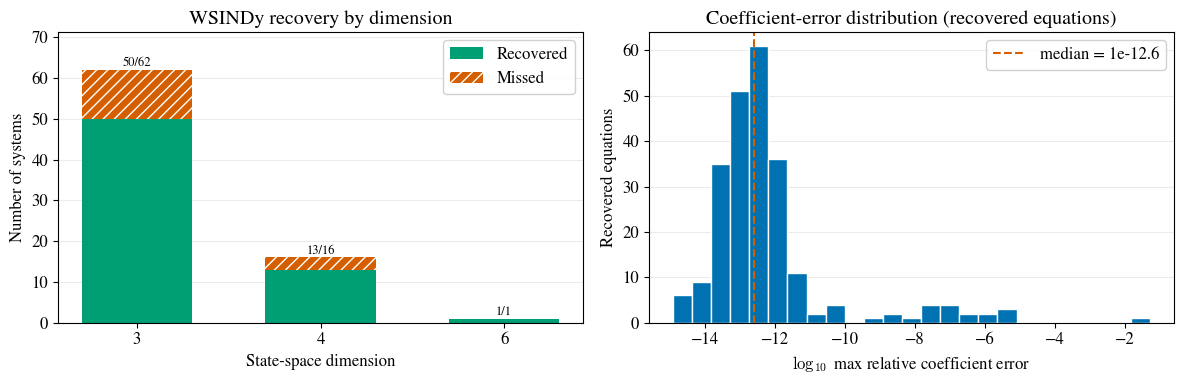

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bp.plot_success_by_dimension(sys_df, ax=axes[0])
bp.plot_coeff_error_hist(eq_df, ax=axes[1])
fig.tight_layout()
plt.show()

In [9]:
# Per-system summary, worst coefficient error first
bp.results_table(sys_df).head(30)

,system,dimension,degree,system_success,n_eq,n_recovered,max_coeff_error,time_s
0,AtmosphericRegime,3,2,False,3,0,2.618318e+00,209.384769
1,Aizawa,3,4,False,3,2,1.329344e+00,18.638505
2,LorenzBounded,3,4,False,3,0,1.153305e+00,32.702338
3,HyperRossler,4,2,False,4,3,1.000000e+00,7.522397
4,WangSun,3,2,False,3,2,1.000000e+00,38.511228
5,Sakarya,3,2,False,3,2,1.000000e+00,54.806681
6,GuckenheimerHolmes,3,3,False,3,1,1.000000e+00,14.393037
7,QiChen,3,2,False,3,2,1.000000e+00,42.720764
8,Rossler,3,2,False,3,2,1.000000e+00,30.151623
9,MooreSpiegel,3,3,False,3,2,1.000000e+00,71.711331


## 4. Spotlight: hyperparameter sweep

Single-fit mode picks one `(m, \lambda)`. For a closer look at a specific equation, the
existing `WSINDy.hyperparameter_sweep` scans the `(m, \lambda)` plane. Below we look at the
Rossler *z*-equation, whose small constant term single-fit tends to threshold out.

100%|██████████| 23/23 [00:07<00:00,  3.22it/s]


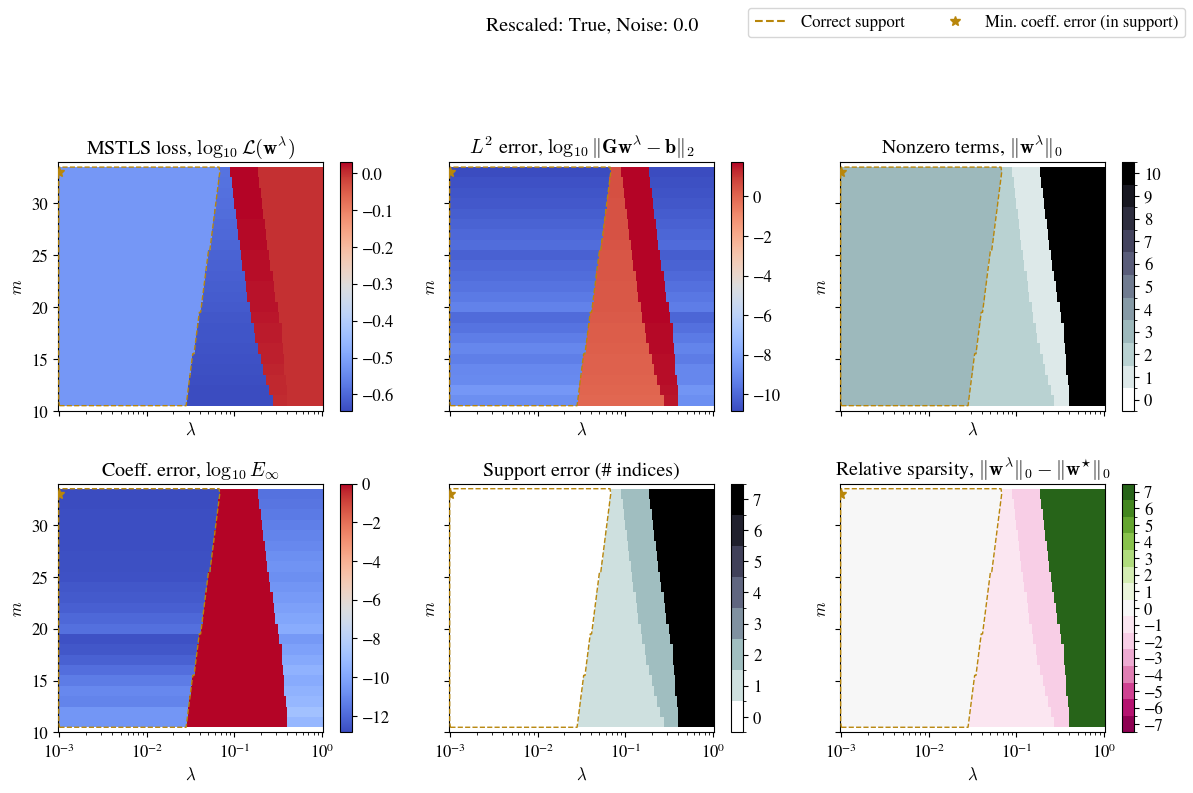

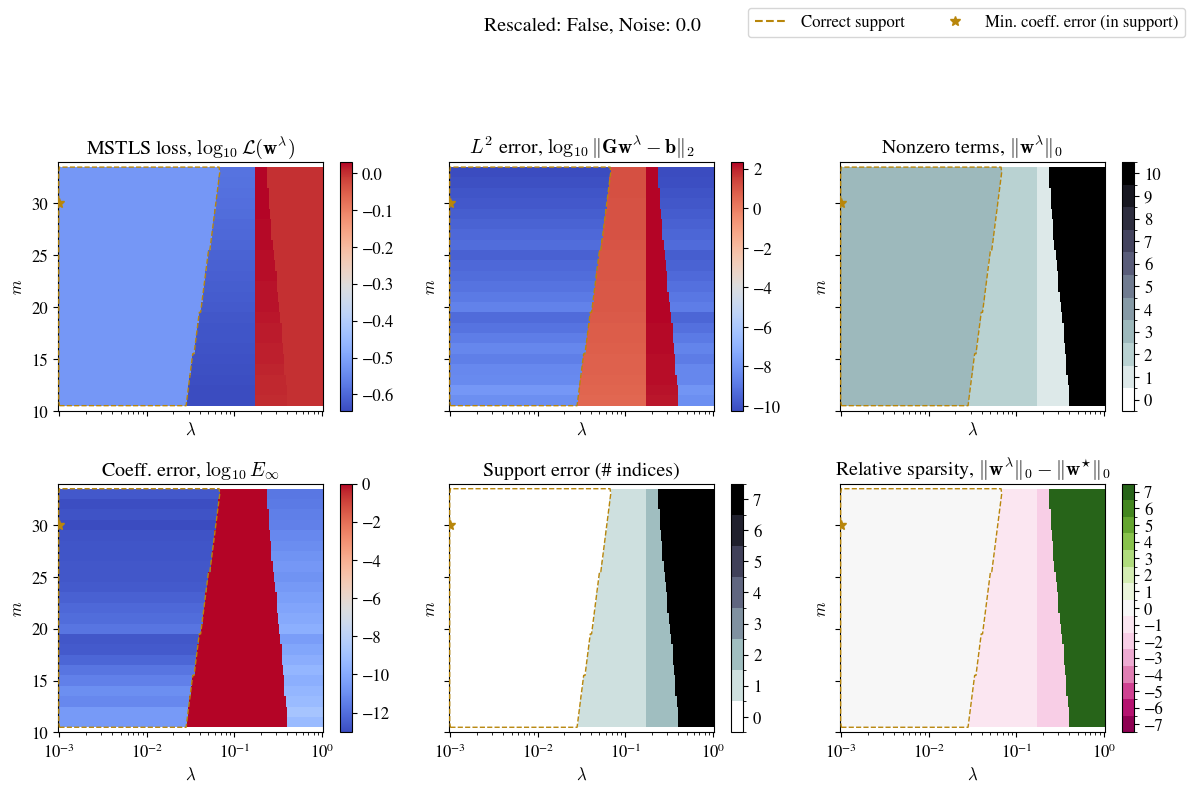

In [7]:
gt = bench.get_ground_truth('Rossler')
beta = bench.build_beta(3, max(2, gt['max_degree']))
t, states, names = bench.load_system('Rossler', noise=0.0)

i = 2  # z-equation
others = [j for j in range(3) if j != i]
local_names = [names[i]] + [names[j] for j in others]
true_coeffs = bench.true_coeffs_for_eq(gt, i, beta)

model = bench.fit_wsindy_ode(states[i], [states[j] for j in others],
                             local_names, t, beta)
_ = model.hyperparameter_sweep(true_coeffs=true_coeffs, noise=0.0)

## 5. Regression test

A fast pass/fail check over a curated subset — use it in CI to catch regressions in the
WSINDy code. Raises `AssertionError` (listing failures) if any curated system stops
recovering.

In [8]:
bench.test_wsindy_recovery()

  Lorenz                 ok
  Halvorsen              ok
  SprottP                ok
  GenesioTesi            ok
  Hadley                 ok
  RabinovichFabrikant    ok
  HenonHeiles            ok
  HyperWang              ok
All 8 regression systems recovered (noise=0, coeff_tol=1e-06).


True